In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


## **DATASET**

In [28]:
df = pd.read_excel('../data/online-retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **PHÂN TÍCH DỮ LIỆU (EDA)**

## Tổng quan dữ liệu

In [29]:
# Kích thước dataset
row, column = df.shape
print(f"Row: {row}, Column: {column}")

Row: 541909, Column: 8


In [30]:
# Thông tin kiểu dữ liệu, null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [31]:
# Kiểm tra giá trị thiếu (null)
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

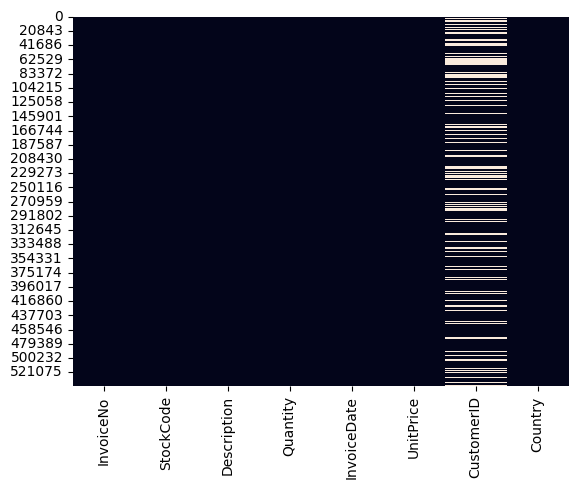

In [32]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()


In [33]:
df = df.drop(columns=["CustomerID"])

In [34]:
# Thống kê cơ bản các cột số
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [35]:
stockcode_map = (
    df.dropna(subset=["Description"])   
      .groupby("StockCode")["Description"]
      .agg(lambda x: x.mode()[0])       
)


df["Description"] = df.apply(
    lambda row: stockcode_map[row["StockCode"]] if pd.isna(row["Description"]) and row["StockCode"] in stockcode_map else row["Description"], 
    axis=1
)

In [36]:
# Kiểm tra dữ liệu có trùng lặp
df.duplicated().any()

np.True_

In [37]:
df.duplicated().sum()


np.int64(5268)

In [38]:
#xử lý trùng lặp
df = df.drop_duplicates()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom


In [39]:
# Kích thước dataset
row, column = df.shape
print(f"Row: {row}, Column: {column}")

Row: 536641, Column: 7


**Nhân xét:**

*   Kích thước dữ liệu là (541909, 8).

*   Có 3 cột là kiểu số, 1 cột kiểu datetime. Còn lại là phân loại.

*   Có 2 cột thiếu dữ liệu(CustomerID (135037) - **XÓA**, Description(1454) - **Điền mode theo StockCode**).


*   Các cột có sự phân tán cao là: Quantity, UnitPrice.

*   Dữ liệu có sự trùng lặp (drop). Kích thước dữ liệu sau khi xử lý trùng lặp (536641, 8)

## Phân tích đơn biến

### Các biến số


In [40]:
# Lấy danh sách cột số
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Các cột số:", numeric_cols)

Các cột số: Index(['Quantity', 'UnitPrice'], dtype='object')


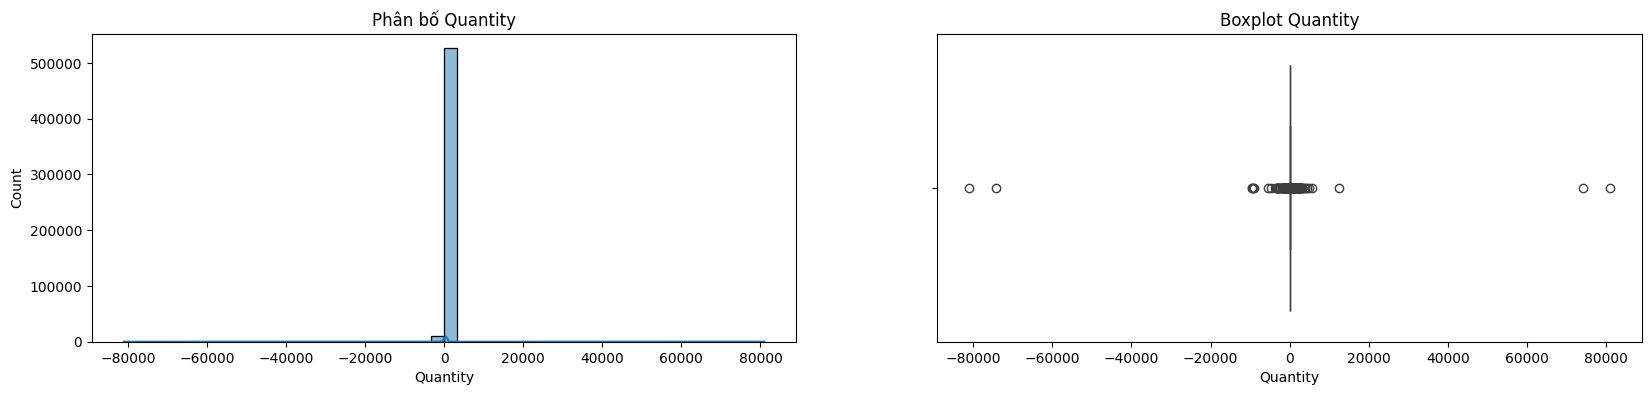

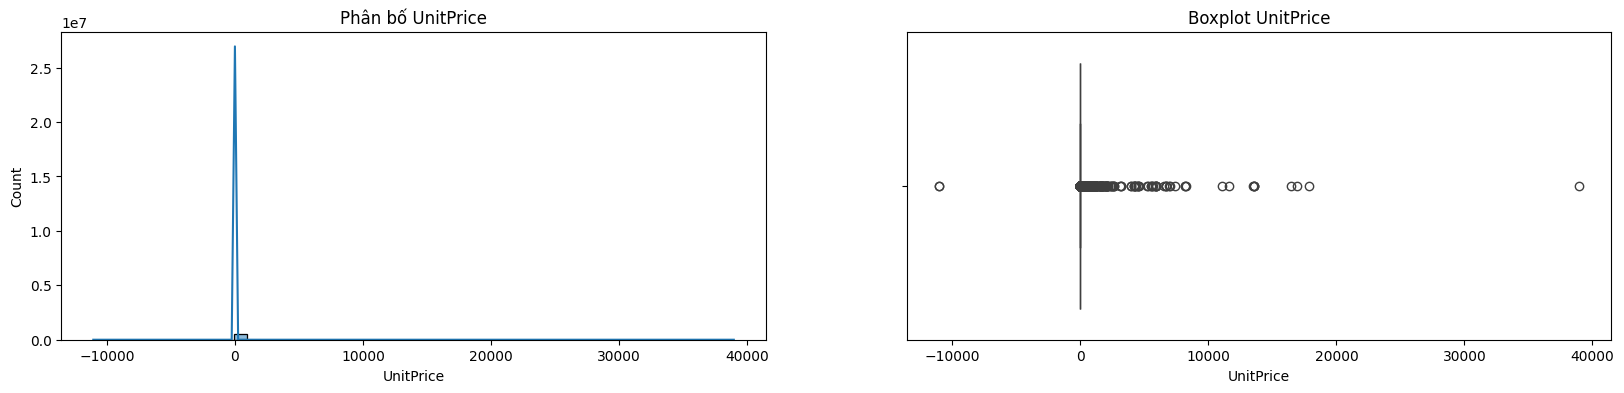

In [48]:
for col in numeric_cols:
    plt.figure(figsize=(20,4))
    
    # Histogram / KDE
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Phân bố {col}")
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    
    plt.show()

***Nhận xét:***
+ Quantity
    * Phần lớn Quantity tập trung quanh giá trị nhỏ (gần 1–20 sản phẩm).

    * Có rất nhiều outliers:

        - Giá trị âm (hàng trả lại), thậm chí đến -80.000.

        - Giá trị cực lớn (80.000 sản phẩm), không hợp lý cho bán lẻ.

    * Boxplot cho thấy phân phối bị lệch mạnh, dữ liệu không chuẩn.
+ UnitPrice    

    * Phần lớn đơn hàng có giá thấp (0–50).

    * Có nhiều outliers:

        - Giá 0 hoặc âm → khả năng lỗi dữ liệu.

        - Giá cực lớn (>10.000, thậm chí gần 40.000) → bất thường, có thể nhập sai.

    * Boxplot cho thấy phân phối bị lệch nặng.

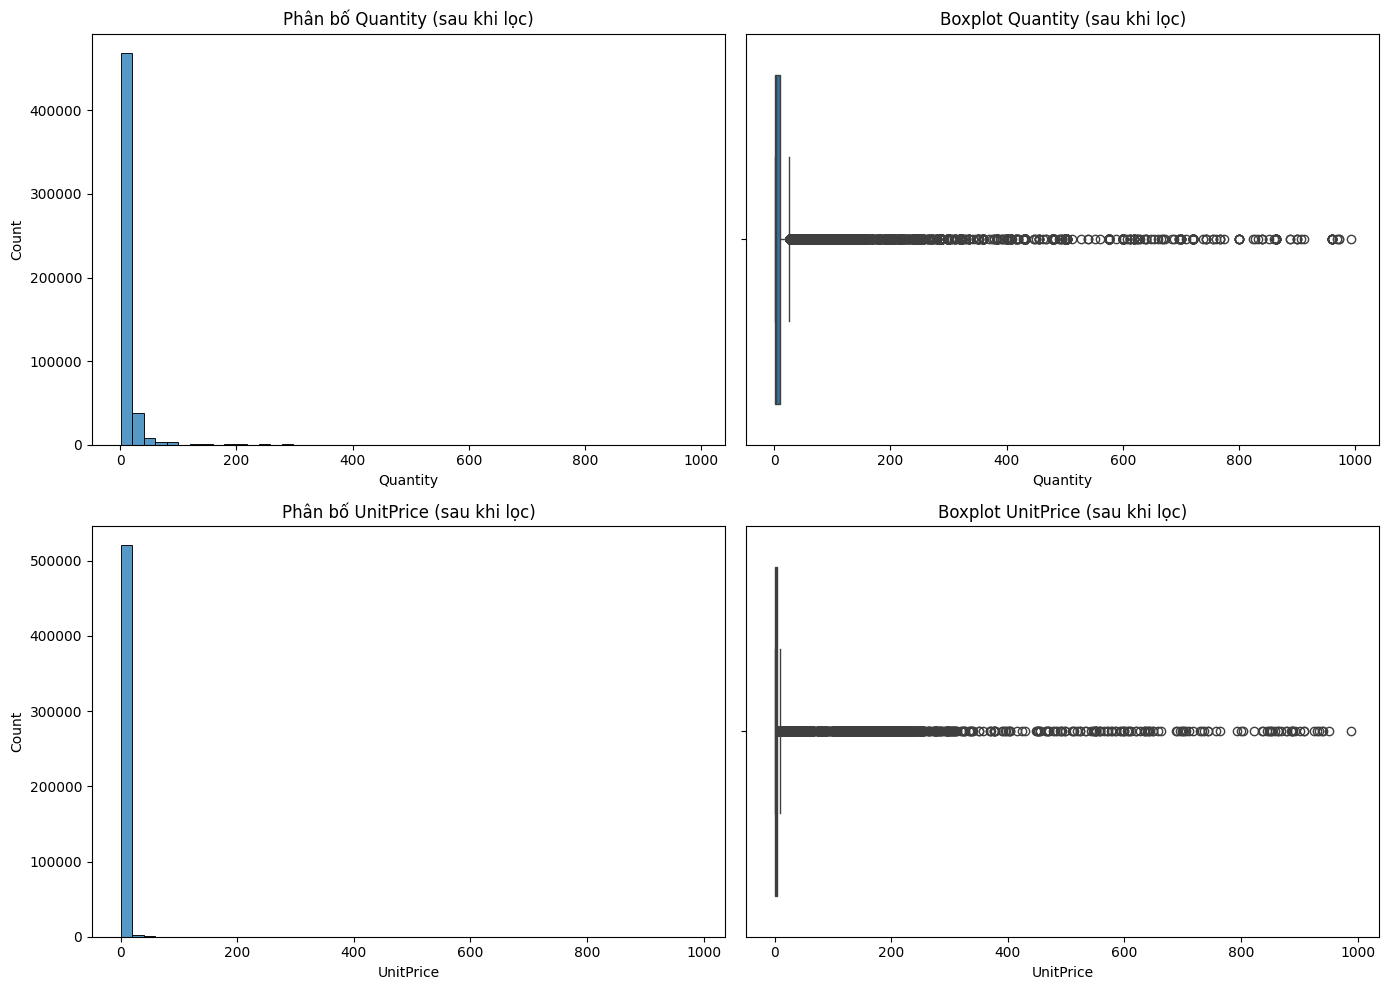

In [62]:
# Lọc dữ liệu
df_filtered = df[(df['Quantity'] > 0) & (df['Quantity'] < 1000) & 
                 (df['UnitPrice'] > 0) & (df['UnitPrice'] < 1000)]

# Vẽ biểu đồ sau khi lọc
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram Quantity
sns.histplot(df_filtered['Quantity'], bins=50, ax=axes[0,0], kde=False)
axes[0,0].set_title("Phân bố Quantity (sau khi lọc)")

# Boxplot Quantity
sns.boxplot(x=df_filtered['Quantity'], ax=axes[0,1])
axes[0,1].set_title("Boxplot Quantity (sau khi lọc)")

# Histogram UnitPrice
sns.histplot(df_filtered['UnitPrice'], bins=50, ax=axes[1,0], kde=False)
axes[1,0].set_title("Phân bố UnitPrice (sau khi lọc)")

# Boxplot UnitPrice
sns.boxplot(x=df_filtered['UnitPrice'], ax=axes[1,1])
axes[1,1].set_title("Boxplot UnitPrice (sau khi lọc)")

plt.tight_layout()
plt.show()


***Nhận xét:***
+ Quantity
    * Histogram (phân bố):
        
        - Phần lớn Quantity tập trung ở mức nhỏ (dưới 50).

        - Tuy nhiên vẫn có một số giá trị rất lớn (hàng trăm đến gần 1000), số lượng này rất ít nhưng làm phân bố bị lệch phải (right-skewed).

    * Boxplot:

        - Xuất hiện rất nhiều outliers (ngoại lệ) với giá trị Quantity lớn vượt xa mức trung bình.

        - Đa số điểm dữ liệu nằm sát trục 0–20.

    
+ UnitPrice    

    * Histogram (phân bố):
        
        - Phần lớn UnitPrice rất nhỏ, tập trung ở khoảng 0–20.

        - Một số giá trị bất thường rất lớn (hàng trăm đến gần 1000) kéo dài đuôi phân bố.

    * Boxplot:

        - Có rất nhiều outliers với giá trị UnitPrice cao bất thường.

        - Đa số dữ liệu nằm sát khoảng giá thấp.

+ Cả Quantity và UnitPrice đều có phân bố lệch phải mạnh, nghĩa là phần lớn dữ liệu nhỏ nhưng vẫn tồn tại một số giá trị ngoại lệ rất lớn.


## Phân tích 2 biến

In [ ]:
#cột doanh thu cho từng dòng
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
country_revenue = df.groupby("Country")["TotalPrice"].sum()


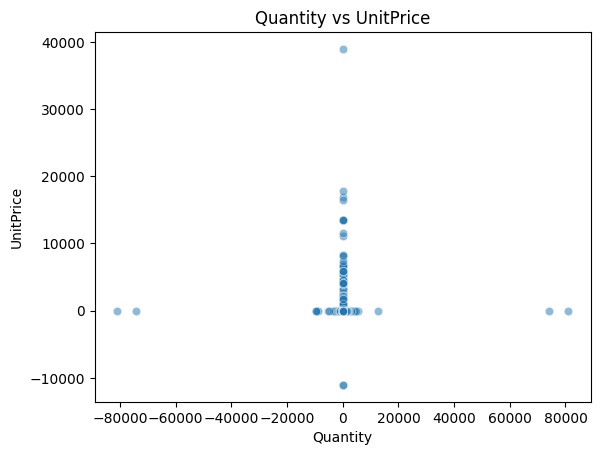

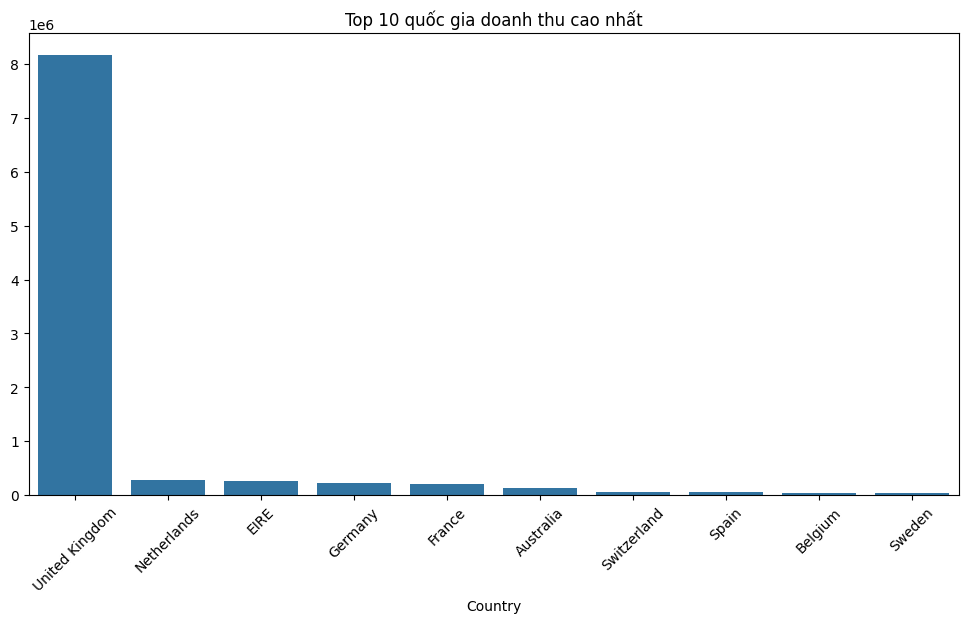

In [51]:
# Scatter plot Quantity vs UnitPrice
sns.scatterplot(x="Quantity", y="UnitPrice", data=df, alpha=0.5)
plt.title("Quantity vs UnitPrice")
plt.show()

# Doanh thu theo quốc gia
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=country_revenue.index[:10], y=country_revenue.values[:10])
plt.xticks(rotation=45)
plt.title("Top 10 quốc gia doanh thu cao nhất")
plt.show()


**Nhận Xét**

* Dataset chứa dữ liệu bất thường (outliers)-> cần xử lý.

* Các điểm bất thường này làm biểu đồ bị “nát”, khiến vùng dữ liệu chính bị nén lại khó quan sát.

* Dataset này mất cân đối về thị trường, tập trung gần như hoàn toàn vào UK.

* United Kingdom chiếm tỷ trọng áp đảo (~80-90%) tổng doanh thu.

* Các quốc gia khác như Netherlands, EIRE, Germany, France chỉ đóng góp một phần rất nhỏ.

* Các quốc gia còn lại trong top 10 (Australia, Switzerland, Spain, Belgium, Sweden) gần như “không đáng kể” so với UK.



Kích thước trước khi lọc: (536641, 8)
Kích thước sau khi lọc: (514959, 8)


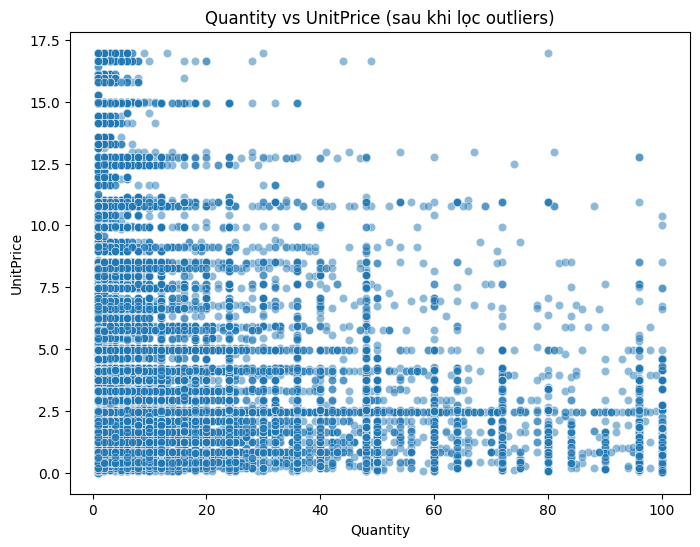

In [ ]:


#Lọc dữ liệu hợp lệ
df_clean = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

#Giới hạn 99% để loại bỏ extreme outliers
q_high = df_clean["Quantity"].quantile(0.99)
p_high = df_clean["UnitPrice"].quantile(0.99)

df_filtered = df_clean[(df_clean["Quantity"] <= q_high) & (df_clean["UnitPrice"] <= p_high)]

print("Kích thước trước khi lọc:", df.shape)
print("Kích thước sau khi lọc:", df_filtered.shape)

#scatter plot sau khi lọc
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_filtered, x="Quantity", y="UnitPrice", alpha=0.5)
plt.title("Quantity vs UnitPrice (sau khi lọc outliers)")
plt.show()


**Nhận Xét**
* Quantity chủ yếu nằm trong khoảng 1 → 100.
* UnitPrice chủ yếu nằm trong khoảng 0 → 18.
* Điều này phản ánh rằng các giao dịch thông thường chỉ liên quan đến số lượng nhỏ sản phẩm và giá trị đơn vị tương đối thấp.
* Dataset chủ yếu gồm các giao dịch nhỏ lẻ, giá thấp, thường là số lượng < 20 và giá < 5.
* Các giao dịch lớn (Quantity cao, UnitPrice cao) là ít và hiếm gặp.

UK: (472618, 8)
Non-UK: (42341, 8)


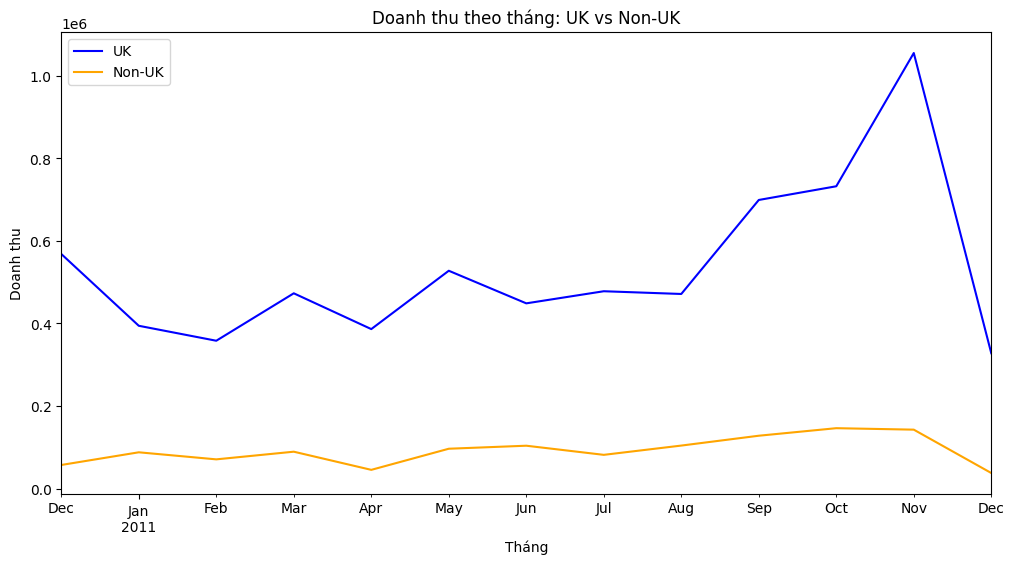

In [ ]:
#UK và Non-UK
df_uk = df_filtered[df_filtered["Country"] == "United Kingdom"]
df_non_uk = df_filtered[df_filtered["Country"] != "United Kingdom"]

print("UK:", df_uk.shape)
print("Non-UK:", df_non_uk.shape)

#Doanh thu theo tháng (UK vs Non-UK)
revenue_uk = df_uk.groupby(df_uk["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()
revenue_non_uk = df_non_uk.groupby(df_non_uk["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()

plt.figure(figsize=(12,6))
revenue_uk.plot(label="UK", color="blue")
revenue_non_uk.plot(label="Non-UK", color="orange")
plt.title("Doanh thu theo tháng: UK vs Non-UK")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")
plt.legend()
plt.show()

# # Top sản phẩm bán chạy ở UK
# top_uk_products = df_uk.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
# plt.figure(figsize=(10,6))
# sns.barplot(x=top_uk_products.values, y=top_uk_products.index, palette="Blues_r")
# plt.title("Top 10 sản phẩm bán chạy nhất ở UK")
# plt.show()

# # Top sản phẩm bán chạy ở Non-UK
# top_non_uk_products = df_non_uk.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
# plt.figure(figsize=(10,6))
# sns.barplot(x=top_non_uk_products.values, y=top_non_uk_products.index, palette="Oranges_r")
# plt.title("Top 10 sản phẩm bán chạy nhất ở Non-UK")
# plt.show()


**Nhận Xét**

* Doanh thu từ UK luôn cao hơn nhiều lần so với Non-UK.

* Cả UK và Non-UK đều có đỉnh doanh thu vào tháng 11.

* Sau tháng 11, doanh thu giảm mạnh vào tháng 12.

* Doanh thu Non-UK có xu hướng tăng từ đầu năm đến tháng 10.

* UK chiếm khoảng 80–90% tổng doanh thu, Non-UK chỉ đóng góp khoảng 10–20%.

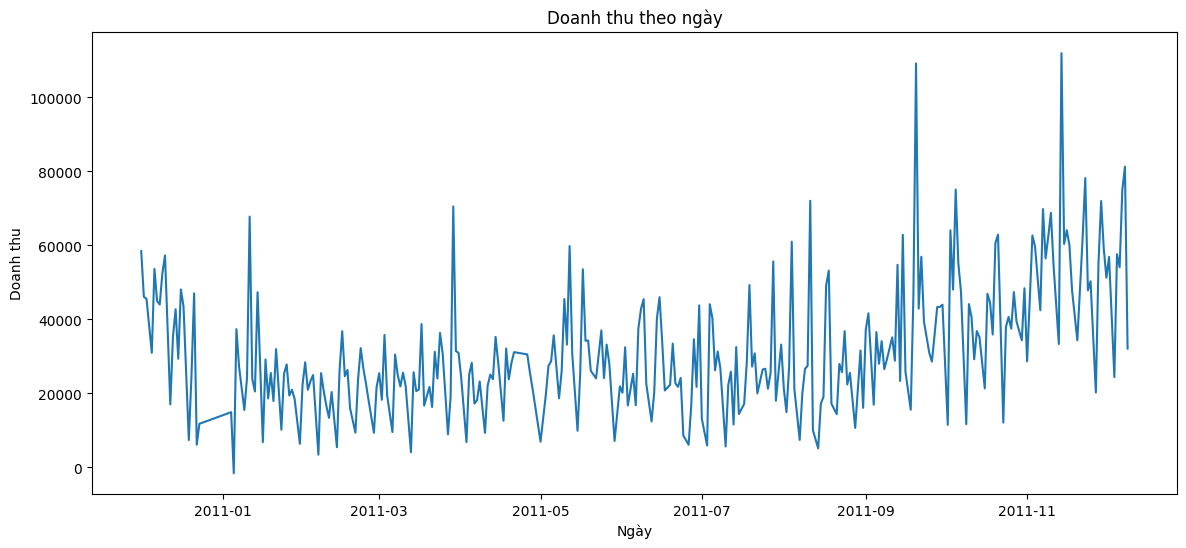

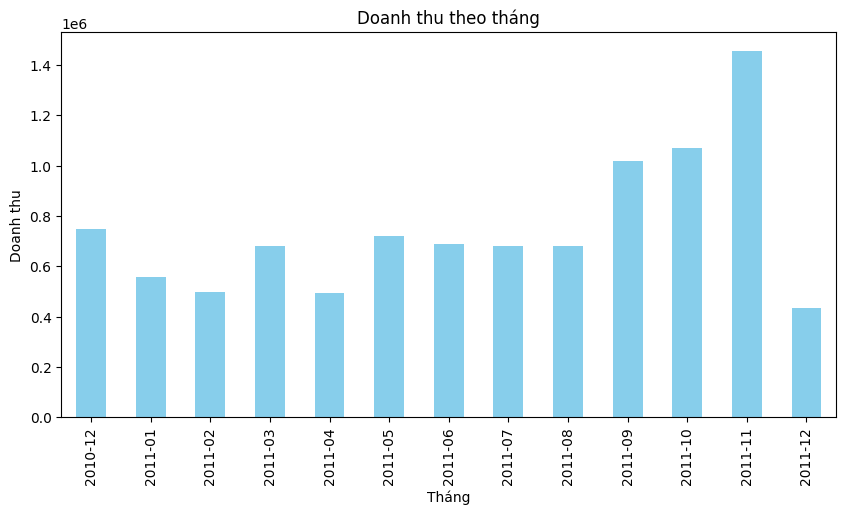

In [52]:
# Doanh thu theo ngày
revenue_per_day = df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"].sum()

plt.figure(figsize=(14,6))
revenue_per_day.plot()
plt.title("Doanh thu theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu")
plt.show()

# Doanh thu theo tháng
revenue_per_month = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()

plt.figure(figsize=(10,5))
revenue_per_month.plot(kind="bar", color="skyblue")
plt.title("Doanh thu theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")
plt.show()


**Nhận Xét**

* Doanh thu thay đổi liên tục, có nhiều dao động lớn giữa các ngày.

* Xuất hiện những “đỉnh” và “đáy” rõ rệt, tức có ngày doanh thu rất cao và cũng có ngày doanh thu gần như bằng 0.

* Giai đoạn đầu năm 2011, doanh thu dao động quanh mức thấp (thường dưới 60000).

* Về cuối năm, tần suất các đỉnh cao (từ 60,000 → hơn 100,000) xuất hiện nhiều hơn → có dấu hiệu tăng trưởng.

* Từ tháng 9 trở đi doanh thu tăng mạnh, đạt đỉnh vào tháng 11/2011 (hơn 1.4 triệu).

* Tháng 4, 2: doanh thu thấp nhất trong năm (~0.5 triệu).

* Tháng 9–11: doanh thu bứt phá, tăng nhanh so với các tháng trước đó.

* Tháng 12: doanh thu giảm mạnh xuống còn khoảng 0.45 triệu (có thể do dữ liệu chưa đủ ngày hoặc thực sự doanh thu giảm).

C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_13752\91592258.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


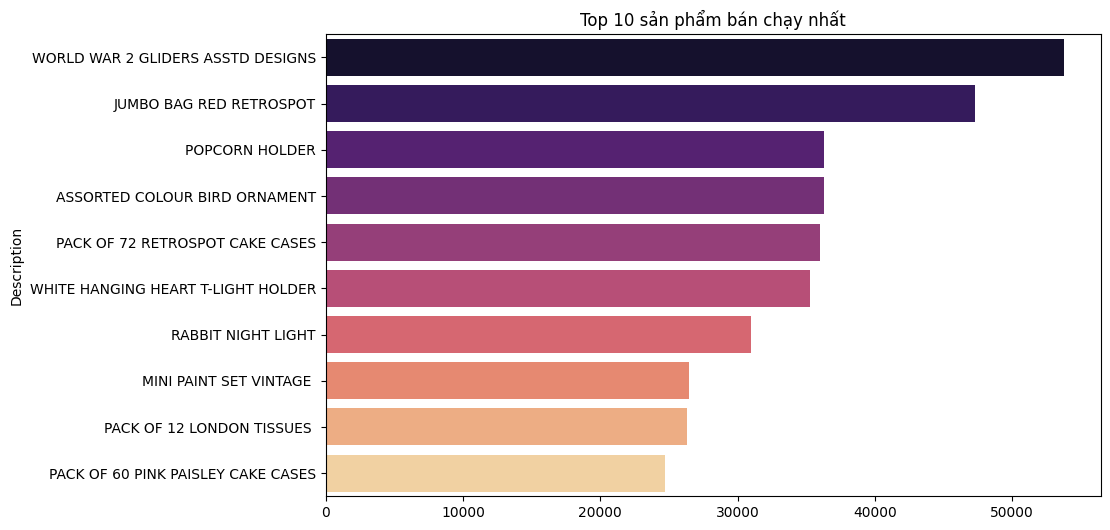

In [53]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 sản phẩm bán chạy nhất")
plt.show()


## Phân tích đa biến

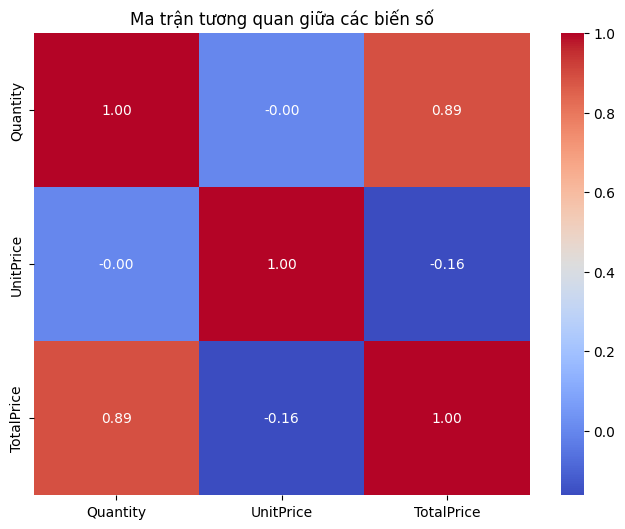

In [56]:
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice"]

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


**Nhận Xét**

* Quantity – TotalPrice: 0.89 (tương quan mạnh, dương)

    - Khi số lượng hàng mua tăng, tổng doanh thu (TotalPrice) cũng tăng mạnh.

* UnitPrice – TotalPrice: -0.16 (tương quan yếu, âm)

    - Giá sản phẩm không ảnh hưởng nhiều đến tổng doanh thu.

* Quantity – UnitPrice: ≈ 0 (không tương quan)

    - Không có mối quan hệ rõ ràng giữa số lượng mua và đơn giá.

* Doanh thu phụ thuộc chủ yếu vào Quantity chứ không phải UnitPrice.

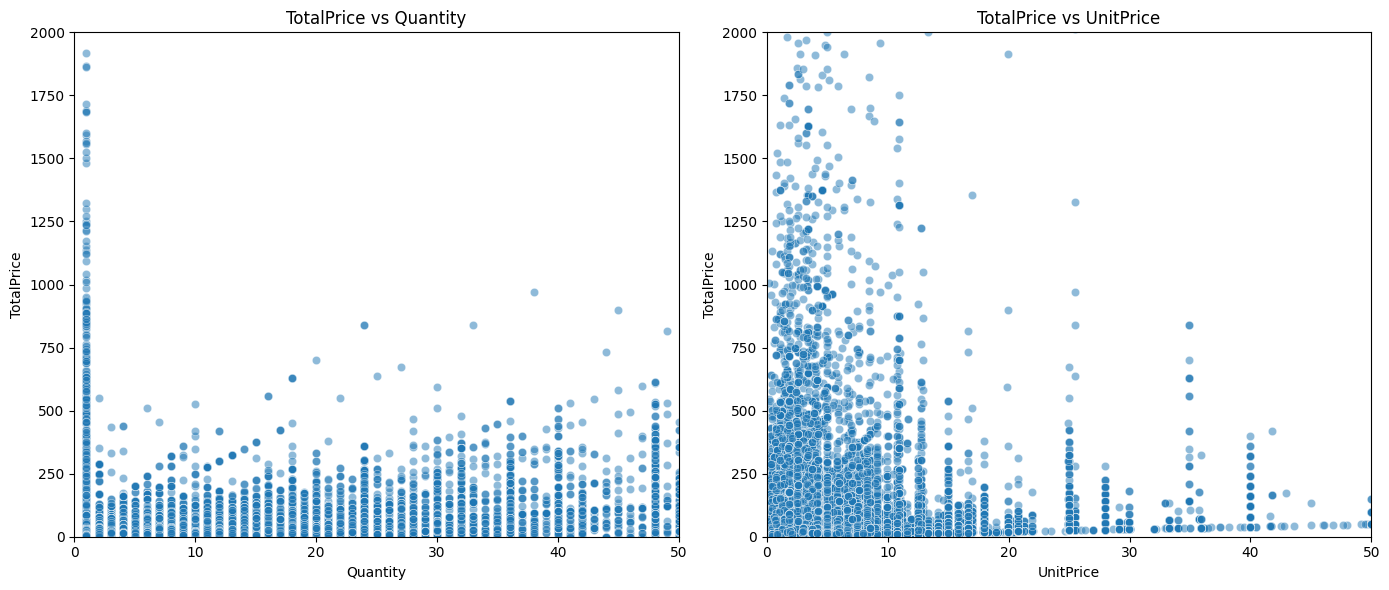

In [64]:
# Tạo cột TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

plt.figure(figsize=(14,6))

#TotalPrice vs Quantity
plt.subplot(1,2,1)
sns.scatterplot(x="Quantity", y="TotalPrice", data=df, alpha=0.5)
plt.title("TotalPrice vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("TotalPrice")
plt.ylim(0, 2000)  
plt.xlim(0, 50) 

# TotalPrice vs UnitPrice
plt.subplot(1,2,2)
sns.scatterplot(x="UnitPrice", y="TotalPrice", data=df, alpha=0.5)
plt.title("TotalPrice vs UnitPrice")
plt.xlabel("UnitPrice")
plt.ylabel("TotalPrice")
plt.ylim(0, 2000)   
plt.xlim(0, 50)

plt.tight_layout()
plt.show()


**Nhận Xét**

* Quantity và TotalPrice: quan hệ tuyến tính dương mạnh (mua càng nhiều, tổng tiền càng cao).

* UnitPrice và TotalPrice: quan hệ yếu, doanh thu chủ yếu đến từ sản phẩm giá thấp – trung bình.